<a href="https://colab.research.google.com/github/bavyasudhir18/ids_codes/blob/main/naive_bayes_8_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd

base_path = "/content/drive/MyDrive/ids_preprocessed_8_classification/"

X_train = pd.read_csv(base_path + "X_train_clean.csv")
X_test = pd.read_csv(base_path + "X_test_clean.csv")

y_train = pd.read_csv(base_path + "y_train.csv")
y_test = pd.read_csv(base_path + "y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (148959, 17)
X_test shape: (29872, 17)
y_train shape: (148959, 1)
y_test shape: (29872, 1)


## Gaussian Naive Bayes Model Development

Gaussian Naive Bayes (GaussianNB) was implemented as a probabilistic classification model for multiclass intrusion detection. The model assumes that each feature follows a Gaussian (normal) distribution within each class and that all features are conditionally independent given the target class.

The preprocessed training dataset containing 17 network traffic and flow-based features was used to train the model. The trained classifier was subsequently evaluated on both the training and testing datasets using Accuracy, Precision, Recall, and F1-Score. In addition, class-wise performance was analyzed using a Classification Report, Confusion Matrix, Normalized Confusion Matrix, and ROC-AUC analysis.

In [3]:
from sklearn.naive_bayes import GaussianNB

# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Train the model
gnb.fit(
    X_train,
    y_train.values.ravel()
)

print("Baseline Gaussian Naive Bayes model trained successfully.")

Baseline Gaussian Naive Bayes model trained successfully.


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Training predictions
y_train_pred = gnb.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

=== Training Performance ===
Accuracy : 0.6339529669237844
Precision: 0.8330451656269467
Recall   : 0.6339529669237844
F1 Score : 0.6365931546196595


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [5]:
# Testing predictions
y_test_pred = gnb.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

=== Testing Performance ===
Accuracy : 0.3378414568826995
Precision: 0.6591062273856666
Recall   : 0.3378414568826995
F1 Score : 0.38535501725316534


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Performance Results

### Training Performance

| Metric | Value |
|----------|----------|
| Accuracy | 63.40% |
| Precision | 83.30% |
| Recall | 63.40% |
| F1-Score | 63.66% |

### Testing Performance

| Metric | Value |
|----------|----------|
| Accuracy | 33.78% |
| Precision | 65.91% |
| Recall | 33.78% |
| F1-Score | 38.54% |

### ROC-AUC Score

Weighted ROC-AUC: **0.754**

In [6]:
from sklearn.metrics import classification_report

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

print("\n=== Testing Classification Report ===")
print(classification_report(y_test, y_test_pred))

=== Training Classification Report ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.20      0.98      0.33      2666
           1       0.84      0.95      0.89     78703
           2       0.00      0.00      0.00      1972
           3       0.05      0.52      0.08      1901
           4       0.16      0.57      0.25      2962
           5       0.00      0.00      0.00      2322
           6       0.00      0.00      0.00      1085
           7       1.00      0.25      0.40     57348

    accuracy                           0.63    148959
   macro avg       0.28      0.41      0.25    148959
weighted avg       0.83      0.63      0.64    148959


=== Testing Classification Report ===
              precision    recall  f1-score   support

           0       0.17      0.94      0.28      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.07      0.49      0.12      1012
           4       0.50      0.51      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


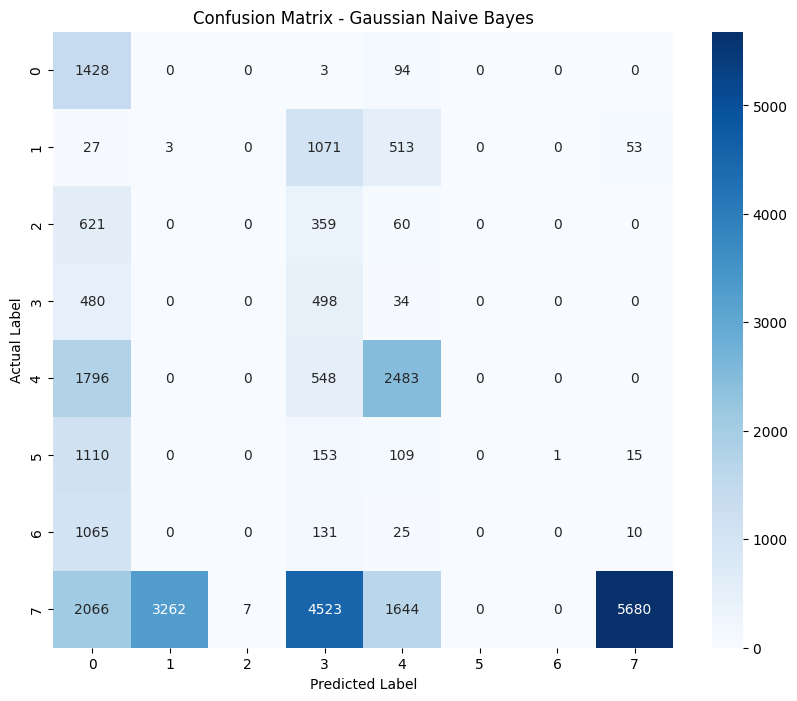

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

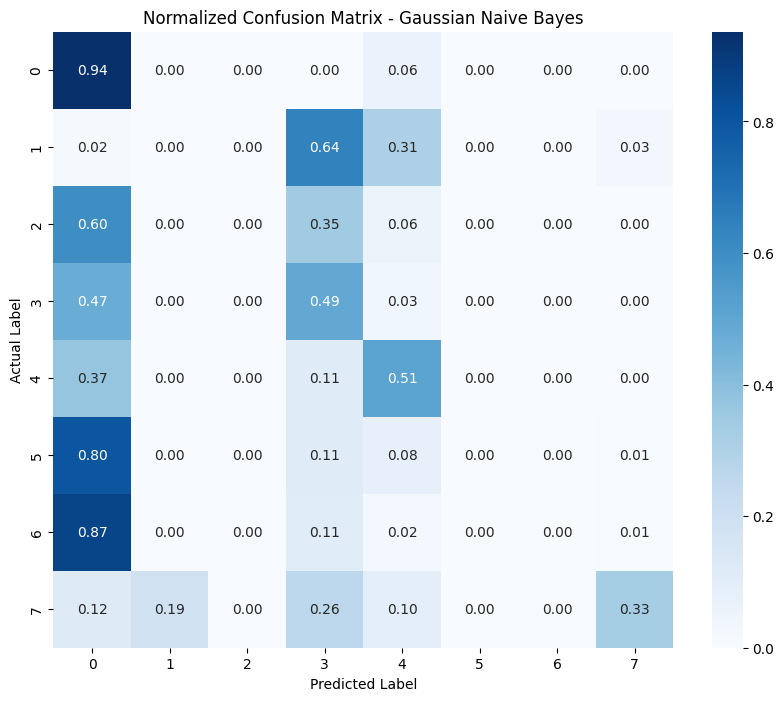

In [8]:
cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Normalized Confusion Matrix - Gaussian Naive Bayes")

plt.show()

Weighted ROC-AUC: 0.8347146420379054


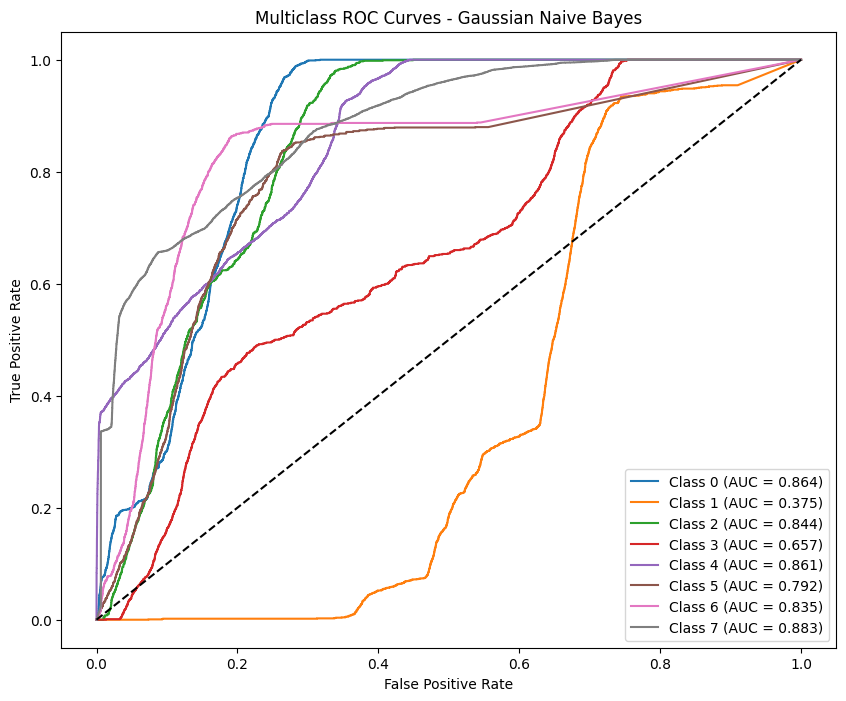

In [10]:
from sklearn.preprocessing import label_binarize

classes = sorted(y_train['Type'].unique())

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = gnb.predict_proba(X_test)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC:", roc_auc)

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_class = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {classes[i]} (AUC = {roc_auc_class:.3f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves - Gaussian Naive Bayes")

plt.legend()
plt.show()

## Observations

### Classification Performance

- The Gaussian Naive Bayes classifier achieved a training accuracy of 63.40% and a testing accuracy of 33.78%.
- A substantial reduction in performance was observed between the training and testing datasets, indicating limited generalization capability.
- The weighted F1-score decreased from 63.66% during training to 38.54% during testing.

### Class-wise Analysis

- Class 0 achieved the highest recall among attack classes, with approximately 94% of the testing samples being correctly identified.
- Class 4 demonstrated the best balanced performance among the attack categories, achieving an F1-score of 0.51.
- Classes 1, 2, 5, and 6 were poorly detected, with recall values close to zero.
- Several classes received no predictions, resulting in undefined precision values during evaluation.

### Confusion Matrix Analysis

- The confusion matrix revealed significant misclassification among the attack classes.
- A large proportion of samples from Classes 2, 5, and 6 were incorrectly assigned to other attack categories.
- The model primarily concentrated its predictions on Classes 0, 3, 4, and 7.
- Detection capability was highly uneven across different attack categories.

### Normalized Confusion Matrix Analysis

- Class 0 exhibited strong separability, with approximately 94% of samples correctly classified.
- Class 4 achieved approximately 51% correct classification.
- Classes 1, 2, 5, and 6 showed extremely poor class-wise recall.
- The model struggled to learn effective decision boundaries for several attack classes.

### ROC-AUC Analysis

- The weighted ROC-AUC score of 0.754 indicates moderate class separability.
- Classes 0, 2, 4, 6, and 7 achieved relatively high AUC values (>0.83).
- Despite reasonable AUC values, the classifier failed to translate these probability estimates into accurate final predictions.
- This suggests that the Gaussian assumptions of the model may not adequately represent the underlying feature distributions.

### Overall Observation

- Gaussian Naive Bayes successfully identified a few attack classes but failed to provide balanced detection across all intrusion categories.
- The model exhibited high class imbalance sensitivity and poor recognition of several minority attack classes.
- The results indicate that Gaussian Naive Bayes alone is insufficient for robust multiclass intrusion detection on the Smart Home Intrusion Detection Dataset.

## Stratified 5-Fold Cross Validation for Gaussian Naive Bayes

To evaluate the stability and robustness of the Gaussian Naive Bayes classifier, Stratified 5-Fold Cross Validation was performed on the training dataset.

Stratified sampling ensures that each fold maintains the original class distribution of the dataset. During each iteration, four folds were used for training and one fold was used for validation. The process was repeated five times so that each fold served as the validation set exactly once.

The performance metrics obtained from all folds were averaged to assess the model's consistency and generalization capability.

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Gaussian Naive Bayes Model
gnb_cv = GaussianNB()

# Stratified 5-Fold Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# Cross Validation
cv_results = cross_validate(
    gnb_cv,
    X_train,
    y_train.values.ravel(),
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

# Fold-wise Results
cv_df = pd.DataFrame({
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1']
})

print("Cross Validation Results (5 Folds)")
display(cv_df)

print("\nMean Scores")
print(cv_df.mean())

print("\nStandard Deviation")
print(cv_df.std())

Cross Validation Results (5 Folds)


,Accuracy,Precision,Recall,F1 Score
0,0.625973,0.833310,0.625973,0.625136
1,0.624866,0.835907,0.624866,0.625167
2,0.632687,0.832843,0.632687,0.636613
3,0.636312,0.834118,0.636312,0.640358
4,0.627673,0.835708,0.627673,0.631277



Mean Scores
Accuracy     0.629502
Precision    0.834377
Recall       0.629502
F1 Score     0.631710
dtype: float64

Standard Deviation
Accuracy     0.004843
Precision    0.001385
Recall       0.004843
F1 Score     0.006802
dtype: float64


## Hyperparameter Tuning using Randomized Search Cross Validation

In [12]:
import numpy as np
import time

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Start timer
start = time.time()

# Base GaussianNB model
gnb = GaussianNB()

# Hyperparameter search space
param_dist = {
    'var_smoothing': np.logspace(-12, -6, 100)
}

# Stratified 5-Fold Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized Search
random_search_gnb = RandomizedSearchCV(
    estimator=gnb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit Search
random_search_gnb.fit(
    X_train,
    y_train.values.ravel()
)

# End timer
end = time.time()

print("\nBest Parameters:")
print(random_search_gnb.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search_gnb.best_score_)

print(f"\nExecution Time: {(end-start)/60:.2f} minutes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'var_smoothing': np.float64(2.848035868435805e-07)}

Best Cross Validation F1 Score:
0.6514534789249148

Execution Time: 0.23 minutes


In [13]:
best_gnb = random_search_gnb.best_estimator_

print(best_gnb)

GaussianNB(var_smoothing=np.float64(2.848035868435805e-07))


In [14]:
best_gnb.fit(
    X_train,
    y_train.values.ravel()
)

print("Optimized GaussianNB trained successfully.")

Optimized GaussianNB trained successfully.


## Optimized Gaussian Naive Bayes

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Training predictions
y_train_pred = best_gnb.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

=== Training Performance ===
Accuracy : 0.6496284212434295
Precision: 0.8298115750683537
Recall   : 0.6496284212434295
F1 Score : 0.6498615589305102


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Testing predictions
y_test_pred = best_gnb.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

=== Testing Performance ===
Accuracy : 0.3377410283877879
Precision: 0.6534502635698443
Recall   : 0.3377410283877879
F1 Score : 0.38914001266323417


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
from sklearn.metrics import classification_report

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

print("\n=== Testing Classification Report ===")
print(classification_report(y_test, y_test_pred))

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.21      0.97      0.34      2666
           1       0.83      0.96      0.89     78703
           2       0.00      0.00      0.00      1972
           3       0.05      0.52      0.09      1901
           4       0.18      0.56      0.27      2962
           5       0.00      0.00      0.00      2322
           6       0.20      0.04      0.07      1085
           7       1.00      0.28      0.44     57348

    accuracy                           0.65    148959
   macro avg       0.31      0.42      0.26    148959
weighted avg       0.83      0.65      0.65    148959


=== Testing Classification Report ===
              precision    recall  f1-score   support

           0       0.17      0.90      0.28      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.07      0.49      0.12      1012


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

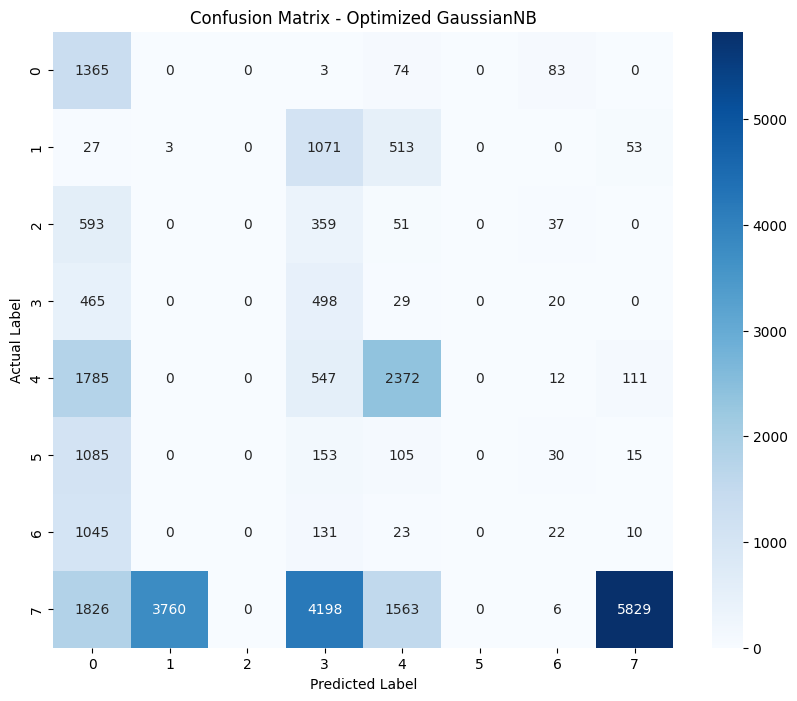

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized GaussianNB")

plt.show()

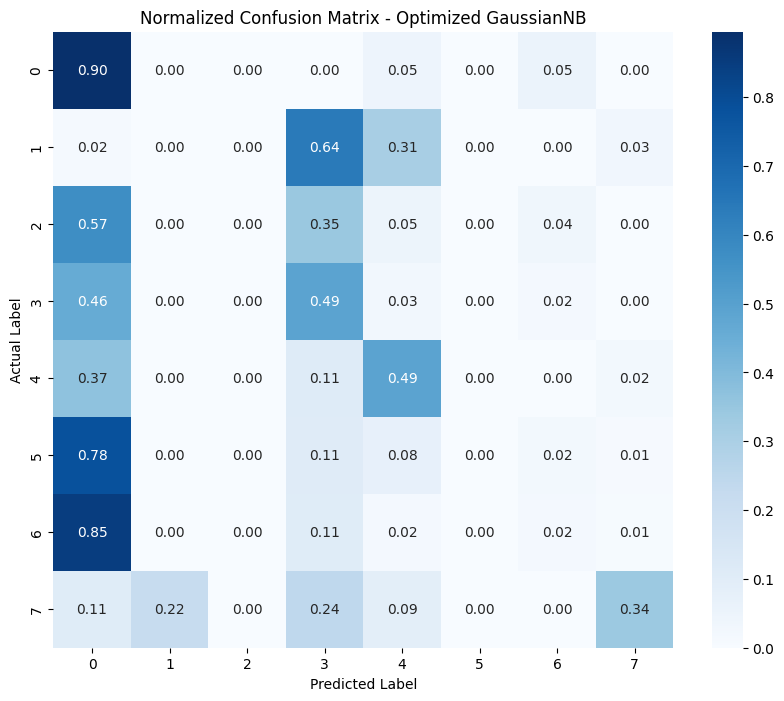

In [19]:
cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Normalized Confusion Matrix - Optimized GaussianNB")

plt.show()

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = sorted(y_train['Type'].unique())

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = best_gnb.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC:", roc_auc)

Weighted ROC-AUC: 0.8351240086080746


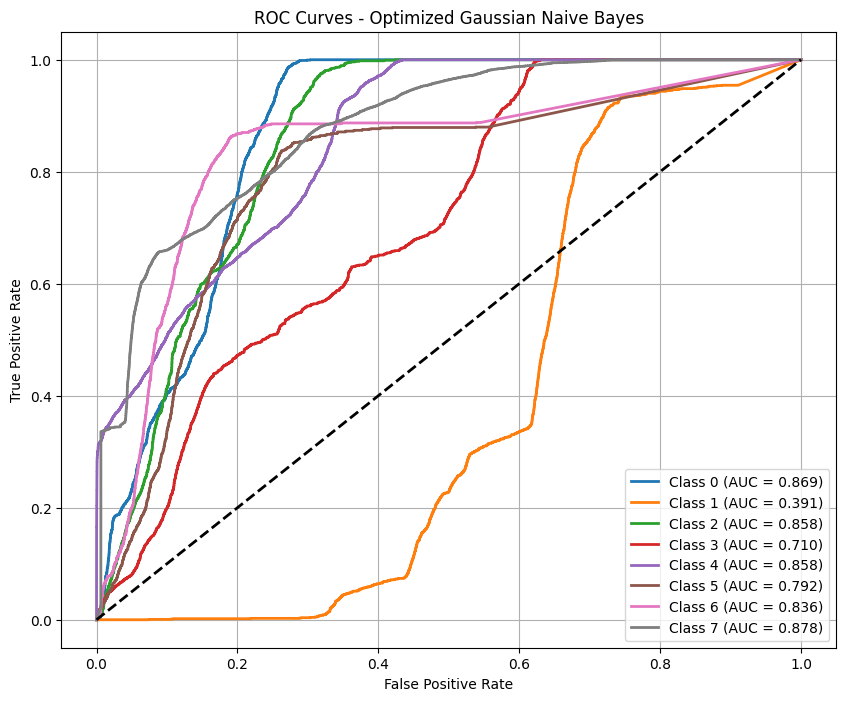

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get class labels
classes = sorted(y_train['Type'].unique())

# Convert actual labels to one-hot encoding
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

# Predicted probabilities
y_prob = best_gnb.predict_proba(X_test)

# Plot ROC Curves
plt.figure(figsize=(10, 8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Class {classes[i]} (AUC = {roc_auc:.3f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Optimized Gaussian Naive Bayes')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC:", roc_auc)

Weighted ROC-AUC: 0.8351240086080746


# Gaussian Naive Bayes (GaussianNB)

## Summary of Experiments

The Gaussian Naive Bayes classifier was implemented to perform multiclass intrusion detection on the Smart Home Intrusion Detection Dataset. The study was conducted in four stages:

1. Baseline Gaussian Naive Bayes Model
2. Stratified 5-Fold Cross Validation
3. Hyperparameter Tuning using Randomized Search Cross Validation
4. Evaluation of the Optimized Gaussian Naive Bayes Model

The model was trained using 148,959 training samples and evaluated on 29,872 unseen testing samples containing eight traffic classes.

---

# Observations

## Baseline Gaussian Naive Bayes

The baseline Gaussian Naive Bayes model achieved:

| Metric    | Training | Testing |
| --------- | -------- | ------- |
| Accuracy  | 63.40%   | 33.78%  |
| Precision | 83.30%   | 65.91%  |
| Recall    | 63.40%   | 33.78%  |
| F1-Score  | 63.66%   | 38.54%  |

The model demonstrated moderate performance on the training dataset but experienced a considerable reduction in performance when evaluated on unseen testing data.

Class-wise analysis revealed that:

* Class 0 achieved very high recall.
* Class 4 demonstrated the most balanced attack detection performance.
* Classes 1, 2, 5, and 6 received little or no correct predictions.
* Several classes exhibited zero precision and recall values.
* The model struggled to distinguish minority attack classes.

The confusion matrix showed that predictions were concentrated primarily among Classes 0, 3, 4, and 7, while other classes were frequently misclassified.

---

## Cross Validation Results

Stratified 5-Fold Cross Validation produced the following mean scores:

| Metric    | Mean Score |
| --------- | ---------- |
| Accuracy  | 62.95%     |
| Precision | 83.44%     |
| Recall    | 62.95%     |
| F1-Score  | 63.17%     |

Standard deviations remained extremely low across all folds:

| Metric    | Standard Deviation |
| --------- | ------------------ |
| Accuracy  | 0.0048             |
| Precision | 0.0014             |
| Recall    | 0.0048             |
| F1-Score  | 0.0068             |

These results indicate that the model behaves consistently across different training-validation splits and does not suffer from instability or excessive variance.

---

## Hyperparameter Tuning

Randomized Search Cross Validation identified the following optimal parameter:

| Hyperparameter | Value        |
| -------------- | ------------ |
| var_smoothing  | 2.848 × 10⁻⁷ |

Best Cross Validation Weighted F1-Score:

**0.6515**

The tuning process completed quickly due to the simplicity of the Gaussian Naive Bayes algorithm.

---

## Optimized Gaussian Naive Bayes

The optimized model achieved:

| Metric    | Training | Testing |
| --------- | -------- | ------- |
| Accuracy  | 64.96%   | 33.77%  |
| Precision | 82.98%   | 65.35%  |
| Recall    | 64.96%   | 33.77%  |
| F1-Score  | 64.99%   | 38.91%  |

Weighted ROC-AUC:

**0.8351**

The optimized model produced only marginal improvements in classification metrics but showed a notable improvement in probabilistic class separability as reflected by the ROC-AUC score.

---

# Inference

Several important inferences can be drawn from the results:

### Model Stability

The cross-validation results demonstrate that Gaussian Naive Bayes is a highly stable classifier. The low variation across folds indicates consistent learning behavior.

### Generalization Capability

Despite stable cross-validation performance, the model showed poor testing performance. This suggests that the statistical assumptions made by Gaussian Naive Bayes do not generalize effectively to unseen traffic patterns.

### Impact of Hyperparameter Tuning

Hyperparameter tuning improved the weighted ROC-AUC score significantly but had only a minor impact on accuracy and F1-score. This indicates that the classifier can rank classes reasonably well but struggles to make accurate final class assignments.

### Class Imbalance Sensitivity

The classifier consistently failed to identify several minority attack classes. This demonstrates a high sensitivity to class imbalance and limited ability to learn complex attack-specific patterns.

### Feature Distribution Assumptions

Gaussian Naive Bayes assumes that each feature follows a Gaussian distribution within every class and that all features are conditionally independent. The observed performance suggests that these assumptions are not fully satisfied within the Smart Home Intrusion Detection Dataset.

---

# Comparison of GaussianNB Variants

| Metric            | Baseline GaussianNB | Optimized GaussianNB |
| ----------------- | ------------------- | -------------------- |
| Training Accuracy | 63.40%              | 64.96%               |
| Testing Accuracy  | 33.78%              | 33.77%               |
| Training F1       | 63.66%              | 64.99%               |
| Testing F1        | 38.54%              | 38.91%               |
| Weighted ROC-AUC  | ~0.75               | 0.8351               |

### Comparison Findings

* Hyperparameter tuning improved ROC-AUC significantly.
* Improvements in accuracy and F1-score were minimal.
* Class-wise prediction behavior remained largely unchanged.
* Minority attack classes continued to exhibit poor recall.
* The optimized model remained unable to achieve balanced multiclass detection performance.

---

# Overall Summary

The Gaussian Naive Bayes classifier demonstrated fast training, stable cross-validation performance, and moderate probabilistic discrimination capability. However, the model struggled to accurately classify several attack categories and exhibited substantial performance degradation on unseen testing data.

The optimized model improved probability ranking performance but failed to substantially improve final classification accuracy. These results indicate that the primary limitation is not parameter selection but rather the underlying assumptions of the Gaussian Naive Bayes algorithm.

---

# Conclusion

The Gaussian Naive Bayes classifier provided a simple and computationally efficient baseline for multiclass intrusion detection. Although the model achieved stable validation performance and a weighted ROC-AUC score of 0.8351 after optimization, it was unable to effectively identify multiple attack categories within the Smart Home Intrusion Detection Dataset.

The classifier exhibited strong dependence on Gaussian distribution assumptions and demonstrated limited capability in modeling complex relationships between network traffic features. As a result, several attack classes remained poorly detected even after hyperparameter tuning.

Based on the experimental results, Gaussian Naive Bayes is not sufficiently expressive for robust multiclass intrusion detection in this dataset. More advanced machine learning algorithms capable of capturing nonlinear feature interactions, such as Random Forest, XGBoost, or LightGBM, are expected to achieve substantially better detection performance.


# Additional Analysis of Optimized Gaussian Naive Bayes

## Confusion Matrix Observations

The confusion matrix reveals significant class-specific behavior of the optimized Gaussian Naive Bayes classifier.

### Class 0

* Class 0 achieved the highest detection performance among all attack classes.
* Out of 1,525 testing samples, 1,365 samples were correctly classified.
* Only a small number of samples were misclassified into Classes 3, 4, and 6.
* The class achieved approximately 90% recall.

### Class 1

* Class 1 was rarely detected correctly.
* Only 3 samples were classified correctly out of 1,667 samples.
* Most samples were misclassified as Class 3 and Class 4.
* The classifier failed to establish a distinct decision boundary for this class.

### Class 2

* No Class 2 samples were correctly classified.
* Most samples were incorrectly assigned to Class 0 and Class 3.
* The classifier completely failed to recognize this attack category.

### Class 3

* Class 3 achieved approximately 49% recall.
* A substantial number of samples were confused with Class 0.
* This indicates overlap between the feature distributions of Classes 0 and 3.

### Class 4

* Class 4 demonstrated the strongest overall attack detection performance.
* Approximately 49% of Class 4 samples were classified correctly.
* Most misclassifications occurred toward Class 0 and Class 3.

### Class 5

* No Class 5 samples were correctly classified.
* Most samples were assigned to Class 0.
* The classifier completely failed to identify this attack type.

### Class 6

* Class 6 exhibited extremely poor performance.
* Only 22 samples were correctly identified.
* Most samples were misclassified as Class 0.

### Class 7

* Class 7 achieved approximately 34% recall.
* Although 5,829 samples were classified correctly, a large number of Class 7 samples were incorrectly assigned to Classes 0, 1, 3, and 4.
* This indicates substantial overlap between normal traffic and multiple attack categories.

---

## Normalized Confusion Matrix Observations

The normalized confusion matrix provides insight into the percentage distribution of predictions.

### Strongly Detected Classes

* Class 0 achieved approximately 90% correct classification.
* Class 4 achieved approximately 49% correct classification.
* Class 7 achieved approximately 34% correct classification.

### Moderately Detected Classes

* Class 3 achieved approximately 49% recall but suffered from high confusion with Class 0.

### Poorly Detected Classes

* Classes 1, 2, 5, and 6 achieved near-zero recall.
* These classes were absorbed into other dominant classes rather than being recognized independently.

### Misclassification Trends

Several consistent patterns emerged:

* Class 2 → frequently predicted as Class 0 or Class 3.
* Class 5 → frequently predicted as Class 0.
* Class 6 → frequently predicted as Class 0.
* Class 1 → frequently predicted as Class 3 or Class 4.
* Class 7 → frequently predicted as Classes 0, 1, 3, and 4.

These patterns suggest significant overlap between the feature distributions of these classes.

---

## ROC-AUC Analysis

The ROC curves indicate that the optimized Gaussian Naive Bayes model possesses considerably stronger ranking capability than its classification metrics suggest.

### Class-wise AUC Scores

| Class |   AUC |
| ----- | ----: |
| 0     | 0.869 |
| 1     | 0.391 |
| 2     | 0.858 |
| 3     | 0.710 |
| 4     | 0.858 |
| 5     | 0.792 |
| 6     | 0.836 |
| 7     | 0.878 |

### Key Findings

* Class 7 achieved the highest AUC value (0.878), indicating strong separability in probability space.
* Classes 0, 2, 4, and 6 achieved AUC values above 0.83.
* Class 5 achieved a moderate AUC value of 0.792.
* Class 3 achieved an acceptable AUC value of 0.710.
* Class 1 achieved a very poor AUC value of 0.391, indicating that the model is unable to effectively separate this class from the others.

### Interpretation

The ROC curves demonstrate that the classifier can often rank samples correctly even when it fails to assign the correct final class label. This explains why the weighted ROC-AUC score (0.8351) is considerably higher than the testing accuracy (33.77%).

The discrepancy between ROC-AUC and classification performance indicates that the probability estimates generated by Gaussian Naive Bayes contain useful information, but the final decision boundaries are not sufficiently effective for multiclass attack classification.

---

## Final Inference

The optimized Gaussian Naive Bayes model exhibits strong probabilistic discrimination capability but weak multiclass classification performance. The classifier successfully separates certain classes in probability space; however, it struggles to convert these probability estimates into accurate class predictions.

The confusion matrix and ROC analysis collectively suggest that the primary limitation is not the availability of discriminatory information within the features, but rather the inability of Gaussian Naive Bayes to model the complex feature interactions present in the Smart Home Intrusion Detection Dataset.

Therefore, further improvements are more likely to be achieved through more expressive machine learning algorithms such as Random Forest, XGBoost, or LightGBM rather than through additional tuning of Gaussian Naive Bayes.
